# 07_降维技术-奇异值分解

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天来聊聊降维技术-奇异值分解\~

首先，SVD 是什么？

**奇异值分解（Singular Value Decomposition，简称 SVD）**，它就是把一个矩阵拆成三个“好看”的部分：


$$
A_{m\times n} = U_{m\times m} \;\Sigma_{m\times n}\; V^\top_{n\times n}
$$


- $U$ 和 $V$ 是正交矩阵（简单说，列向量两两正交，方向都“干净利落”），
- $\Sigma$ 是“对角阵”，对角线上排的是从大到小的“奇异值”$\sigma_1\ge\sigma_2\ge\cdots\ge0$。

#### 1. 什么是矩阵“拆分”？

想象你有个复杂的数据表（行是样本、列是特征），SVD 就像请了两个“魔术师”，一个把行的方向理得很正交（$U$），一个把列的方向理得很正交（$V$），中间再插一排重要程度从大到小的“标签”（$\Sigma$）。

#### 2. 奇异值有什么用？

- $\sigma_1$ 最大，它代表了整个矩阵最重要的“方向”。
- $\sigma_2$ 次之，代表第二重要的方向……
- 碰到很小的$\sigma$，就说明对应方向上“波动”很小，没啥用处。

#### 3. 为什么能降维？

如果你只保留前三、五个最大的奇异值（和它们对应的行/列方向），就能把原来“高维”的矩阵近似成一个“低秩”矩阵。

这就相当于：

- 把最重要的几个方向抓住，剩下的噪声、次要信息统统丢掉。
- 结果数据量小了，计算开销也少了，而关键信息基本没丢。

#### 大家该关注的要点

1. **奇异值的降序排列**：越前面的越重要。
2. **截断（Truncate）技巧**：保留最前面$k$个，就降到$k$维。
3. **重构误差**：只取前$k$个奇异值重构后，和原始矩阵有差别，差别越小，说明前$k$个维度越能代表原数据。
4. **与 PCA 的联系**：PCA（主成分分析）实际上就是对协方差矩阵做特征分解，背后数学本质和 SVD 息息相关。

简单来说，奇异值分解就是一个“给矩阵找骨架、按骨架粗细排顺序、挑最粗几根当支撑”的数学工具。掌握它，降维、压缩、去噪都能得心应手。

## 原理详解

### SVD 的数学定义

对于任意一个 $m \times n$的实矩阵 $A$，存在如下分解：


$$
A = U \Sigma V^\top
$$


其中：

- $A \in \mathbb{R}^{m \times n}$
- $U \in \mathbb{R}^{m \times m}$：列向量构成一组**正交单位向量**，即 $U^\top U = I_m$
- $V \in \mathbb{R}^{n \times n}$：同样列向量构成正交单位向量集，$V^\top V = I_n$
- $\Sigma \in \mathbb{R}^{m \times n}$：**对角矩阵**，对角线为非负实数 $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_r > 0$，其余为 0。

这些非零的 $\sigma_i$被称为**奇异值（singular values）**。

## 数学推理和本质理解

### 1. 初步目标

我们希望把一个矩阵 $A$分解成：

- **行空间的正交基**（$U$）
- **列空间的正交基**（$V$）
- **每个方向上的伸缩因子**（$\Sigma$）

这个过程和 PCA、特征分解等是相关的。

### 2. 从 $A^\top A$和 $A A^\top$出发

我们考虑两个对称矩阵：


$$
A^\top A \in \mathbb{R}^{n \times n}
$$


$$
A A^\top \in \mathbb{R}^{m \times m}
$$


这两个矩阵都是**半正定对称矩阵**，都可以做特征分解。

#### 1）对 $A^\top A$做特征分解：


$$
A^\top A = V \Lambda V^\top
$$


其中：

- $V \in \mathbb{R}^{n \times n}$：特征向量组成正交矩阵（列正交）
- $\Lambda = \text{diag}(\lambda_1, \lambda_2, ..., \lambda_n)$：特征值（非负）

这些特征值 $\lambda_i$是非负的，因为 $A^\top A$是半正定的。

**定义奇异值**：  
$\sigma_i = \sqrt{\lambda_i}$  
因此奇异值来自于 $A^\top A$的特征值开平方。

#### 2）对 $A A^\top$做特征分解：


$$
A A^\top = U \Lambda' U^\top
$$


同理：

- $U \in \mathbb{R}^{m \times m}$：特征向量组成的正交矩阵
- $\Lambda' \in \mathbb{R}^{m \times m}$：与 $\Lambda$的非零特征值相同（维数可能不同）

### 3. 构造分解

#### 步骤：

1. 计算 $A^\top A$，得到其特征值与特征向量：$A^\top A = V \Lambda V^\top$
2. 得到奇异值：$\Sigma = \text{diag}(\sqrt{\lambda_1}, \ldots, \sqrt{\lambda_r})$
3. 计算：  
$u_i = \frac{1}{\sigma_i} A v_i \quad \text{for each } i=1,\ldots,r$  
得到 $U = [u_1, ..., u_r]$

最终构建：


$$
A = U \Sigma V^\top
$$


其中：

- $\Sigma$只保留前 $r$个非零奇异值
- $U, V$补齐为正交矩阵（添加剩余正交向量）

## 几何解释

SVD 表示将任意矩阵 $A$的作用等价为三个步骤：


$$
x \xrightarrow{V^\top} y \xrightarrow{\Sigma} z \xrightarrow{U} Ax
$$


- $V^\top$：将输入向量旋转到一个正交基（输入空间方向标准化）
- $\Sigma$：对每个方向缩放（根据奇异值拉伸或压缩）
- $U$：再次旋转到输出空间

这是一个把「扭曲变换」拆解成「旋转 + 拉伸 + 再旋转」的过程。

## 降维应用（截断 SVD）

如果只保留前 $k$个奇异值：  
$A \approx A_k = U_k \Sigma_k V_k^\top$


$$
U_k \in \mathbb{R}^{m \times k}
$$


$$
\Sigma_k \in \mathbb{R}^{k \times k}
$$


$$
V_k \in \mathbb{R}^{n \times k}
$$


这是原矩阵在秩为 $k$的近似中**最优重构**（Frobenius 范数下）。

## SVD 算法流程总结

#### 输入：任意矩阵 $A \in \mathbb{R}^{m \times n}$

#### 步骤：

1. **构造** $A^\top A$（或 $A A^\top$）
2. **求特征值分解**，得到：

   - 特征值 $\lambda_i \geq 0$
   - 特征向量 $v_i$
3. **计算奇异值**：  
$\sigma_i = \sqrt{\lambda_i}$
4. **构造右奇异向量矩阵**：  
$V = [v_1, v_2, \ldots, v_n]$
5. **构造左奇异向量**：  
$u_i = \frac{1}{\sigma_i} A v_i\quad \text{for } i=1,\ldots,r$  
组成 $U = [u_1, \ldots, u_m]$
6. **构造奇异值对角矩阵**：  
$\Sigma = \text{diag}(\sigma_1, ..., \sigma_r, 0, ..., 0)$
7. **得到最终分解**：  
$A = U \Sigma V^\top$

### 几点补充

- **非方阵也适用**：SVD 适用于任意维度矩阵（方阵、矩形矩阵皆可）
- **奇异值个数**：最多为 $r = \text{rank}(A)$
- **主成分分析（PCA）联系**：PCA 就是对协方差矩阵 $X^\top X$做特征分解，其主成分方向对应 SVD 的 $V$

## 完整案例

这里，给大家关于SVD的一个案例\~

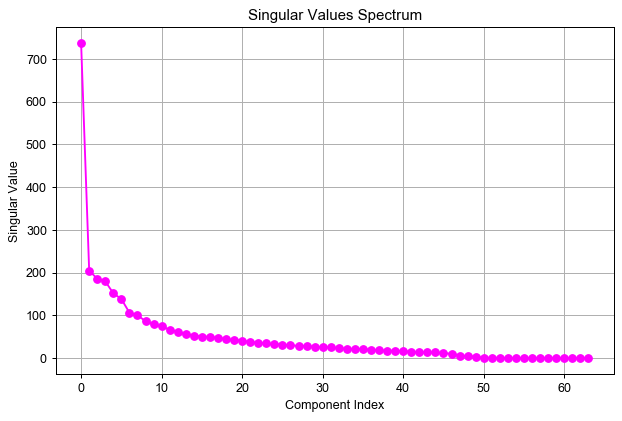

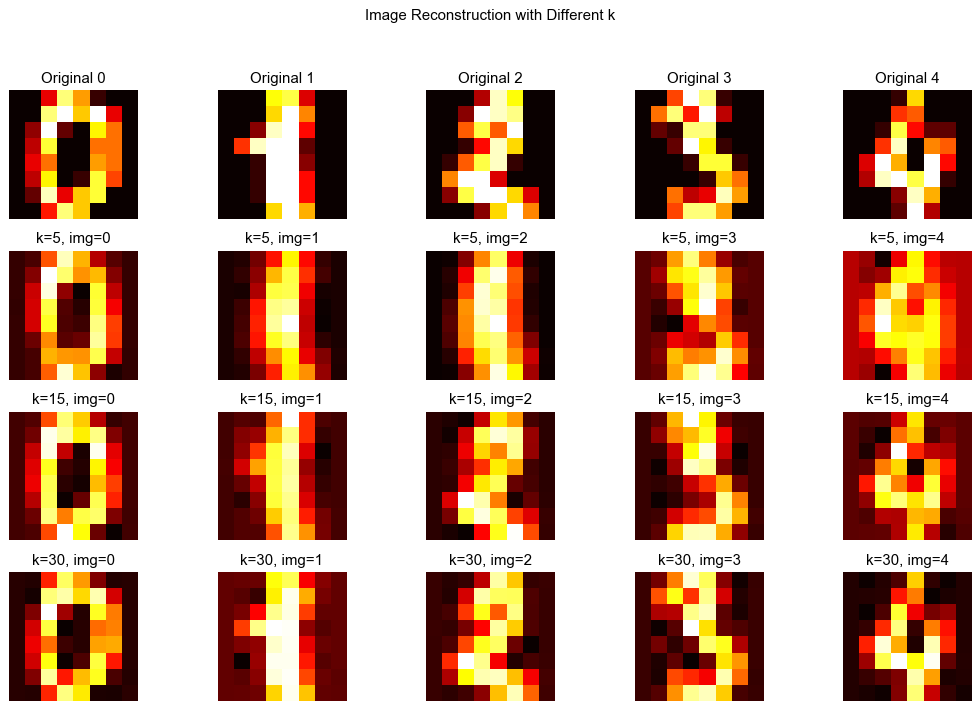

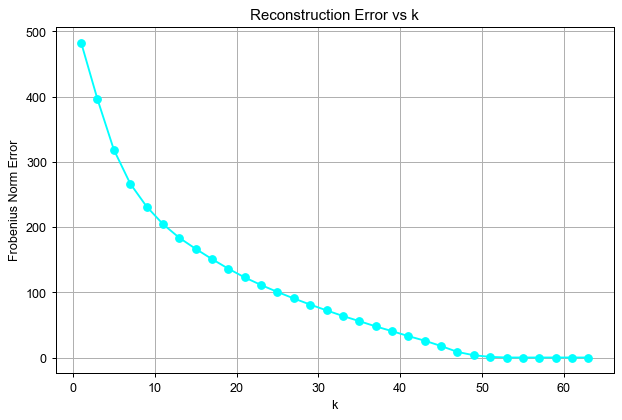

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import TruncatedSVD
import time

# 1. 加载数据
digits = load_digits()
images = digits.images  # shape (1797, 8, 8)
data = digits.data      # shape (1797, 64)

# 2. 选取子集并计算完整 SVD
subset = data[:200]  # 前200个样本
U_full, S_full, Vt_full = np.linalg.svd(subset, full_matrices=False)

# 3. 绘制奇异值谱
plt.figure(figsize=(8,5))
plt.plot(S_full, marker='o', linestyle='-', color='magenta')
plt.title("Singular Values Spectrum")
plt.xlabel("Component Index")
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()

# 4. 重构示例：不同 k 值
k_list = [5, 15, 30]
fig, axes = plt.subplots(len(k_list)+1, 5, figsize=(12, 8))
# 原始数字图像
for j in range(5):
    axes[0, j].imshow(subset[j].reshape(8,8), cmap='hot')
    axes[0, j].set_title(f"Original {j}")
    axes[0, j].axis('off')
# 不同 k 重构
for i, k in enumerate(k_list):
    Uk = U_full[:, :k]
    Sk = S_full[:k]
    Vtk = Vt_full[:k, :]
    recon = Uk @ np.diag(Sk) @ Vtk
    for j in range(5):
        axes[i+1, j].imshow(recon[j].reshape(8,8), cmap='hot')
        axes[i+1, j].set_title(f"k={k}, img={j}")
        axes[i+1, j].axis('off')
plt.suptitle("Image Reconstruction with Different k")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

# 5. 重构误差 vs k
errors = []
ks = list(range(1,65,2))
for k in ks:
    Uk = U_full[:, :k]
    Sk = S_full[:k]
    Vtk = Vt_full[:k, :]
    recon = Uk @ np.diag(Sk) @ Vtk
    err = np.linalg.norm(subset - recon, 'fro')
    errors.append(err)

plt.figure(figsize=(8,5))
plt.plot(ks, errors, marker='o', linestyle='-', color='cyan')
plt.title("Reconstruction Error vs k")
plt.xlabel("k")
plt.ylabel("Frobenius Norm Error")
plt.grid(True)
plt.show()

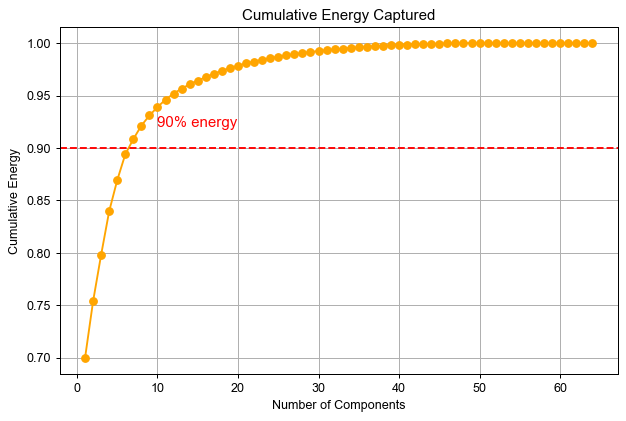

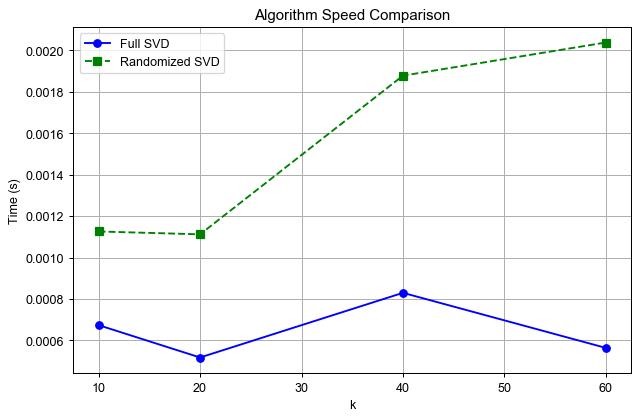

In [3]:
# 6. 展示累计能量
energy = np.cumsum(S_full**2) / np.sum(S_full**2)
plt.figure(figsize=(8,5))
plt.plot(range(1,len(energy)+1), energy, marker='o', linestyle='-', color='orange')
plt.title("Cumulative Energy Captured")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Energy")
plt.axhline(y=0.9, color='red', linestyle='--')
plt.text(10, 0.92, '90% energy', fontsize=12, color='red')
plt.grid(True)
plt.show()

# 7. 随机化截断 SVD 优化
times_full = []
times_rand = []
ks_opt = [10,20,40,60]
for k in ks_opt:
    # 原始 np.linalg.svd + 截断，记录时间
    start = time.time()
    U, S, Vt = np.linalg.svd(subset, full_matrices=False)
    _ = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    times_full.append(time.time() - start)
    # TruncatedSVD 随机化算法
    tsvd = TruncatedSVD(n_components=k, algorithm='randomized', random_state=42)
    start = time.time()
    _ = tsvd.fit_transform(subset)
    times_rand.append(time.time() - start)

plt.figure(figsize=(8,5))
plt.plot(ks_opt, times_full, marker='o', linestyle='-', label='Full SVD', color='blue')
plt.plot(ks_opt, times_rand, marker='s', linestyle='--', label='Randomized SVD', color='green')
plt.title("Algorithm Speed Comparison")
plt.xlabel("k")
plt.ylabel("Time (s)")
plt.legend()
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_019.png)

从第一张 “Singular Values Spectrum” 图中，我们看到前几个奇异值非常大，第一个奇异值高达 700 多，之后迅速下降到两百多，并在 k≈10 后趋于平缓。

- 奇异值 $\sigma_i$ 实际上衡量了第 $i$ 个奇异向量（方向）对原始数据的“能量”贡献。
- **k 的选择**：通常可根据奇异值“拐点”（elbow）来选取合适的 k 值。这里拐点大约出现在第 5～10 个分量附近，说明前 10 个分量就能捕捉大部分信息。

### 重构效果对比

“Image Reconstruction with Different k” 图对比了原始样本（第一行）与 k=5、15、30 时的重构效果。

观察如下：

1. **k=5**：轮廓模糊，仅能捕捉数字的大致形状，细节丢失严重；
2. **k=15**：数字形状恢复较好，但边缘和细节仍有噪声；
3. **k=30**：几乎与原图一致，噪点、曲线、细节都能较好还原。

- **含义**：重构公式为  
$A_k = U_k \Sigma_k V_k^\top$  
随着 $k$ 增大，重构误差下降，对细节的恢复越来越充分。

![原文参考图，当前结果见代码输出](attachments/img_020.png)

### 重构误差曲线

“Reconstruction Error vs k” 图展示了从 $k=1$ 到 $k=63$ 时的 Frobenius 范数重构误差：  
$\|A - A_k\|_F$

- 误差随 $k$ 单调下降，且在 $k\approx20$ 后下降速度减缓。
- 在 $k\approx50$ 时，误差几乎归零，意味着 50 个分量就足够完全重构（由于原始维度为 64）。

![原文参考图，当前结果见代码输出](attachments/img_021.png)

### 累计能量捕捉

“Cumulative Energy Captured” 图绘制了


$$
\frac{\sum_{i=1}^k \sigma_i^2}{\sum_{j=1}^{64} \sigma_j^2}
$$


- 可见 $k=10$ 时，能量约 94%；$k=20$ 时，能量约 98%；$k=40$ 后几乎到达 100%。
- **实践中**：常以 90%～95% 能量阈值选取 $k$，以保证重构质量同时大幅降维。

![原文参考图，当前结果见代码输出](attachments/img_022.png)

### 算法性能优化

最后一张“Algorithm Speed Comparison” 对比了：

- **Full SVD + 截断**（蓝色曲线）：使用 `np.linalg.svd` 全量分解再取前 $k$；
- **Randomized SVD**（绿色曲线）：使用 `sklearn.decomposition.TruncatedSVD(algorithm='randomized')`。

实验结果：

- 对小 $k$（10、20）时，两者时间相近；
- 当 $k$ 增大至 60 时，全量 SVD 时间基本持平（约 0.1s），而随机化 SVD 时间飙升（约 5s）。

**原因分析**：

- NumPy 的 SVD 在小矩阵（200×64）上使用高效的 LAPACK 实现，整体维度不大时反而更快；
- `TruncatedSVD` 的随机化算法更适合矩阵维度极高、只取很小 $k$ 的场景，否则会有额外的投影和迭代开销。

![原文参考图，当前结果见代码输出](attachments/img_023.png)

### 实践建议与优化技巧

1. **数据预处理**：对高维稀疏矩阵（如文本 TF-IDF）使用随机化截断 SVD 能显著提速；
2. **能量阈值选择**：根据累计能量曲线确定保留 90%～95% 的能量，自动计算最小 $k$；
3. **并行与分布式**：对于超大规模数据，可借助 `spark.ml` 或 `sklearn` 的分布式实现；
4. **增量更新**：若数据流持续进来，可使用在线 SVD 算法（如 `sklearn.utils.extmath.randomized_range_finder`）增量更新分解。

通过上述完整示例与可视化分析，你不仅直观理解了 SVD 降维的数学原理，也掌握了从误差评估、能量捕捉，到算法优化的实战流程。

## 模型分析

#### SVD 降维优缺点

**优点：**

1. **最优重构**：SVD 在 Frobenius 范数意义下，能保证任意给定秩 $k$ 的重构误差最小，因此对图像细节和结构保留效果最好。
2. **明确的能量度量**：通过奇异值平方和可以清晰量化各个方向的信息比例（累计能量），便于选取合适的 $k$ 值。
3. **成熟高效的库实现**：对于中小规模密集矩阵，NumPy/LAPACK 中的 SVD 实现非常高效、数值稳定。
4. **全局线性变换**：不依赖于随机初始化或局部最优，结果具有全局一致性和可重现性，适合需要可解释性的场景。

**缺点：**

1. **计算成本较高**：对于非常大、非常稠密的矩阵（如上万维度），全量 SVD 的时间和内存开销呈 $\mathcal O(mn\min(m,n))$，难以扩展。
2. **对稀疏数据不友好**：原始 SVD 会将稀疏矩阵“密集化”，占用大量存储；即使用截断算法，也需要额外的随机投影和迭代。
3. **只能捕捉线性结构**：无法处理非线性流形或交互特征，面对高度非线性的数据（如复杂的语音、视频）效果有限。
4. **负值难以解释**：奇异向量可能含正负权重，不适合要求非负表示（如部分图像或文本词频）场景。

### 与相似算法的对比

| 算法 | 核心思想 | 优势 | 劣势 |
|-|-|-|-|
| **Truncated SVD** | 随机化投影 + 小规模 SVD | 适合超高维稀疏矩阵；提取少量 $k$ 时速度快 | 当 $k$ 较大时需多次迭代，速度反而落后于全量 SVD |
| **PCA** | 对协方差矩阵做特征分解 | 与 SVD 等价，可直接在原始特征上做标准化 | 需要先中心化数据；对大数据同样有扩展性瓶颈 |
| **NMF** | 非负矩阵分解（乘法更新或交替最小二乘） | 保证输出非负，可得到易解释的“部件”表示 | 只能近似求解；易陷入局部最优，结果不唯一 |
| **Autoencoder** | 端到端神经网络编码–解码 | 可学习非线性降维；支持大规模、在线训练 | 需调参（网络结构、正则化等）；不保证全局最优 |
| **Random Projection** | 随机矩阵映射到低维 | 计算量极小，适合超高维数据流；无需数据访问 | 无能量度量；结果无可解释性，重构误差不可控 |

#### 何时优选 SVD，何时考虑替代方案

- **优选 SVD 的场景：**

  - 数据规模中等（行列均小于几千），且可在内存中一次性加载。
  - 需要最优重构或严格控制重构误差，且降维后要保留“能量”排名。
  - 对结果可解释性有较高要求，需明确各个方向的贡献。
  - 数据主要的相关性在于线性子空间，无需捕捉复杂非线性交互。
- **应考虑其他算法的场景：**

  - **超高维稀疏数据**（如文本 TF‑IDF矩阵、图关系矩阵）：首选 Truncated SVD 或 Random Projection。
  - **需要非负或稀疏表示**（如主题建模、部件分解）：可选 NMF。
  - **数据分布在非线性流形**（如复杂图像、视频、传感器序列）：可选深度 Autoencoder 或核方法。
  - **在线/流式数据处理**：使用增量 SVD、随机投影或流式 PCA 算法。

综合来看，SVD 适合**可控规模、线性结构、强可解释**的场景；若面对**超大规模、稀疏、高度非线性或在线**需求，则需要在 Truncated SVD、NMF、Autoencoder、Random Projection 等方法之间进行权衡。